In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost
import xgboost as xgb
import sklearn

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

## #10 Boosted Decision Trees

In [9]:
"""reading in the data from files"""

data_bg_train = pd.read_csv("BDT_background_train.txt", sep=" ",header=None)
data_signal_train = pd.read_csv("BDT_signal_train.txt", sep=" ",header=None)
data_bg_test = pd.read_csv("BDT_background_test.txt", sep=" ",header=None)
data_signal_test = pd.read_csv("BDT_signal_test.txt", sep=" ",header=None)

data_bg_train

,0,1,2
0,1.881091,2.375811,8.285966
1,2.402203,3.008130,13.030533
2,4.061991,3.379065,25.449992
3,1.320657,2.376048,6.492450
4,2.256665,3.187502,13.150233
...,...,...,...
3995,1.917689,3.437489,12.908225
3996,0.778973,2.220448,4.810126
3997,1.750617,3.100183,10.729395
3998,2.957329,3.242218,17.054168


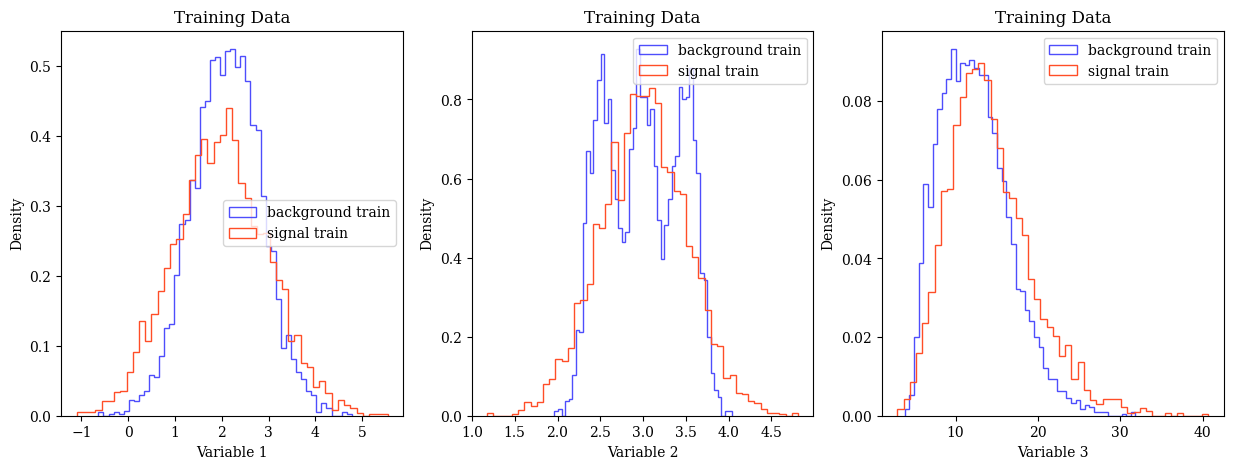

In [10]:
"""making histograms of the data"""

fig,ax=plt.subplots(1,3, figsize=(15,5))

ax[0].hist(data_bg_train[0], bins=50, density=True, histtype="step", label="background train", color=my_cmap(0.1))
ax[0].hist(data_signal_train[0], bins=50, density=True, histtype="step", label="signal train", color=my_cmap(0.9))
ax[0].set_xlabel("Variable 1")
ax[0].set_ylabel("Density")
ax[0].set_title("Training Data")
ax[0].legend()

ax[1].hist(data_bg_train[1], bins=50, density=True, histtype="step", label="background train", color=my_cmap(0.1))
ax[1].hist(data_signal_train[1], bins=50, density=True, histtype="step", label="signal train", color=my_cmap(0.9))
ax[1].set_xlabel("Variable 2")
ax[1].set_ylabel("Density")
ax[1].set_title("Training Data")
ax[1].legend()

ax[2].hist(data_bg_train[2], bins=50, density=True, histtype="step", label="background train", color=my_cmap(0.1))
ax[2].hist(data_signal_train[2], bins=50, density=True, histtype="step", label="signal train", color=my_cmap(0.9))
ax[2].set_xlabel("Variable 3")
ax[2].set_ylabel("Density")
ax[2].set_title("Training Data")
ax[2].legend()



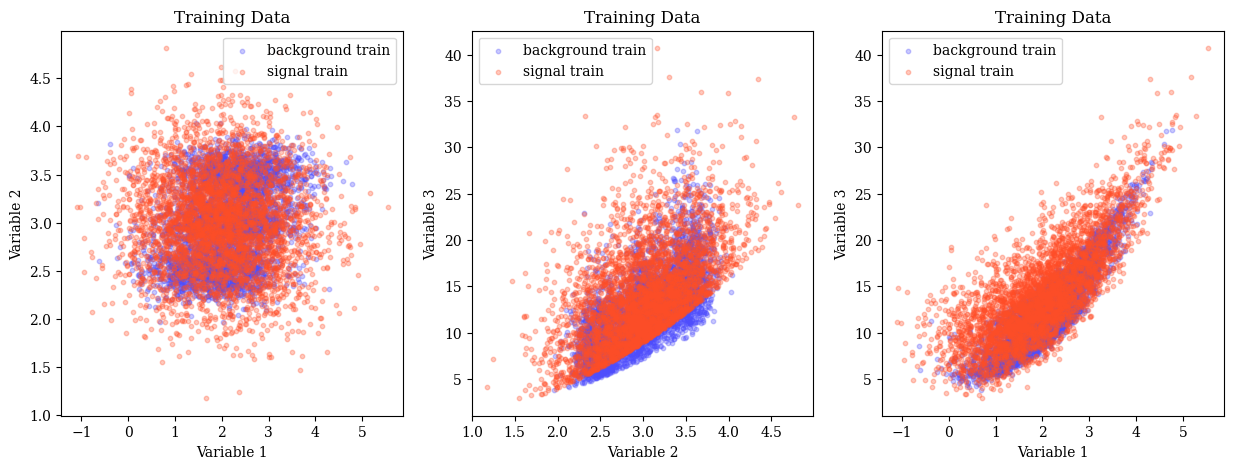

In [11]:
"""plotting data in 2d - 3 different combinations of variables"""

fig,ax=plt.subplots(1,3, figsize=(15,5))

ax[0].scatter(data_bg_train[0], data_bg_train[1], label="background train", color=my_cmap(0.1), s=10, alpha=0.3)
ax[0].scatter(data_signal_train[0], data_signal_train[1], label="signal train", color=my_cmap(0.9), s=10, alpha=0.3)
ax[0].set_xlabel("Variable 1")
ax[0].set_ylabel("Variable 2")
ax[0].set_title("Training Data")
ax[0].legend()

ax[1].scatter(data_bg_train[1], data_bg_train[2], label="background train", color=my_cmap(0.1), s=10, alpha=0.3)
ax[1].scatter(data_signal_train[1], data_signal_train[2], label="signal train", color=my_cmap(0.9), s=10, alpha=0.3)
ax[1].set_xlabel("Variable 2")
ax[1].set_ylabel("Variable 3")
ax[1].set_title("Training Data")
ax[1].legend()

ax[2].scatter(data_bg_train[0], data_bg_train[2], label="background train", color=my_cmap(0.1), s=10, alpha=0.3)
ax[2].scatter(data_signal_train[0], data_signal_train[2], label="signal train", color=my_cmap(0.9), s=10, alpha=0.3)
ax[2].set_xlabel("Variable 1")
ax[2].set_ylabel("Variable 3")
ax[2].set_title("Training Data")
ax[2].legend()


In [14]:
data_signal_train

,0,1,2
0,2.475303,2.608148,12.929561
1,1.061436,3.681113,14.677241
2,1.265686,3.237551,12.083696
3,2.790318,3.379381,19.206095
4,0.091745,2.642437,6.990892
...,...,...,...
3995,3.321130,3.072963,20.473005
3996,1.703948,2.922941,11.447021
3997,0.376233,3.146673,10.043102
3998,0.216834,3.433255,11.834259


In [ ]:
"""training a BDT classifier"""
#train data
data_train = pd.concat([data_signal_train, data_bg_train], ignore_index=True)
labels_train = np.concatenate([np.ones(len(data_signal_train)), np.zeros(len(data_bg_train))])
#test data
data_test= pd.concat([data_signal_test, data_bg_test], ignore_index=True)
labels_test = np.concatenate([np.ones(len(data_signal_test)), np.zeros(len(data_bg_test))])


#execute the training of the BDT classifier
xgb_cls=xgb.XGBClassifier(n_estimators=100)
xgb_cls.fit(data_train, labels_train,verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_cls.evals_result()

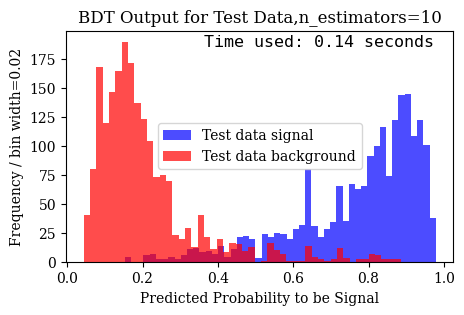

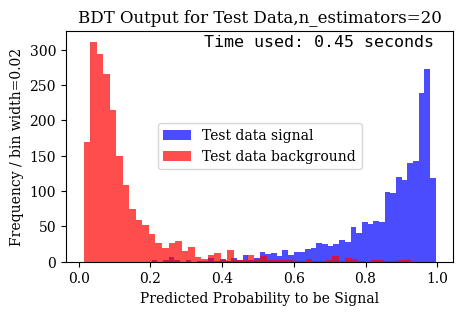

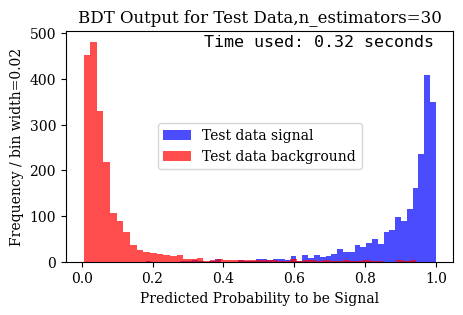

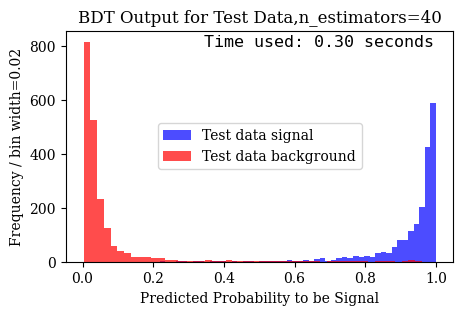

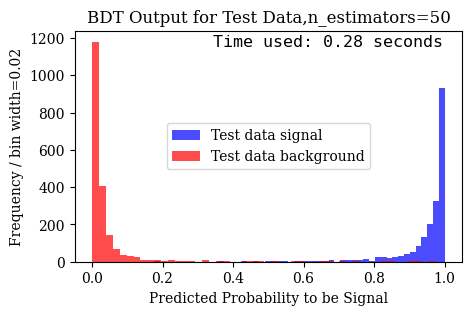

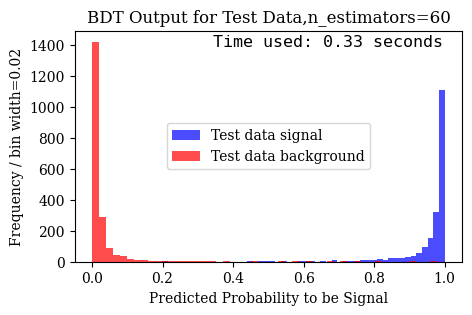

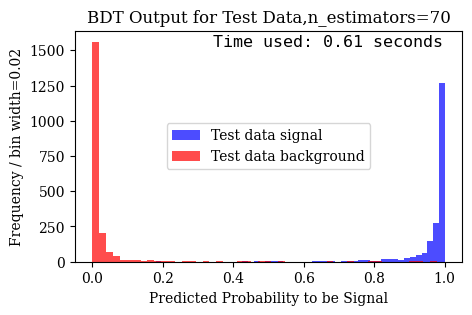

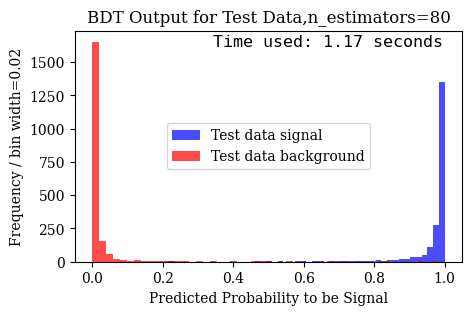

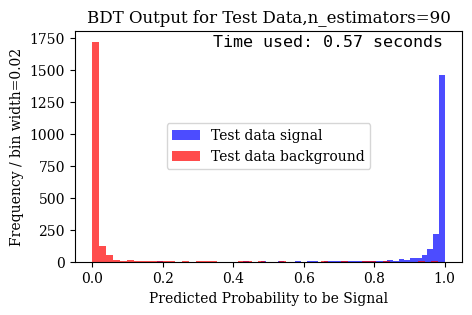

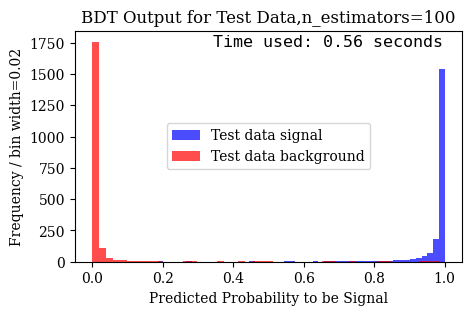

In [ ]:
"""time used to train the BDT classifier"""
#see https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.training
import time


for n in range(10, 101, 10):
    #execute the training of the BDT classifier
    start_time = time.time()
    xgb_cls=xgb.XGBClassifier(n_estimators=n)
    xgb_cls.fit(data_train, labels_train,verbose=False)
    stop_time = time.time()
    time_used = stop_time - start_time

    pred_proba_signal = xgb_cls.predict_proba(data_signal_test)
    pred_proba_bg = xgb_cls.predict_proba(data_bg_test)

    """make histogram of test data with the BDT output"""
    plt.hist(pred_proba_signal[:, 1], bins=50, alpha=0.7,color='blue', label='Test data signal')
    plt.hist(pred_proba_bg[:, 1], bins=50, alpha=0.7,color='red', label='Test data background')
    plt.xlabel('Predicted Probability to be Signal')
    plt.ylabel('Frequency / bin width=0.02')
    plt.text(0.95, 0.95, f'Time used: {time_used:.2f} seconds', transform=plt.gca().transAxes, **text_style)
    plt.title(f'BDT Output for Test Data,n_estimators={n}')
    plt.legend(loc='center')
    plt.show()


## #2 now with 16 variables